In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('SpotifyFeatures.csv')

features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
            'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'popularity']
print(f"~*~ first rows of the dataset: \n{df.head()}")
print(f"\n~*~ statistics of columns: \n{df[features].describe()}")

df_pop= df[df['popularity'] >= 85].copy()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_pop[features])
print(f"\n~*~ scaled data (filtered): {df_pop.shape}")

~*~ first rows of the dataset: 
   genre        artist_name                        track_name  \
0  Movie     Henri Salvador       C'est beau de faire un Show   
1  Movie  Martin & les fées  Perdu d'avance (par Gad Elmaleh)   
2  Movie    Joseph Williams    Don't Let Me Be Lonely Tonight   
3  Movie     Henri Salvador    Dis-moi Monsieur Gordon Cooper   
4  Movie       Fabien Nataf                         Ouverture   

                 track_id  popularity  acousticness  danceability  \
0  0BRjO6ga9RKCKjfDqeFgWV           0         0.611         0.389   
1  0BjC1NfoEOOusryehmNudP           1         0.246         0.590   
2  0CoSDzoNIKCRs124s9uTVy           3         0.952         0.663   
3  0Gc6TVm52BwZD07Ki6tIvf           0         0.703         0.240   
4  0IuslXpMROHdEPvSl1fTQK           4         0.950         0.331   

   duration_ms  energy  instrumentalness key  liveness  loudness   mode  \
0        99373   0.910             0.000  C#    0.3460    -1.828  Major   
1       1373

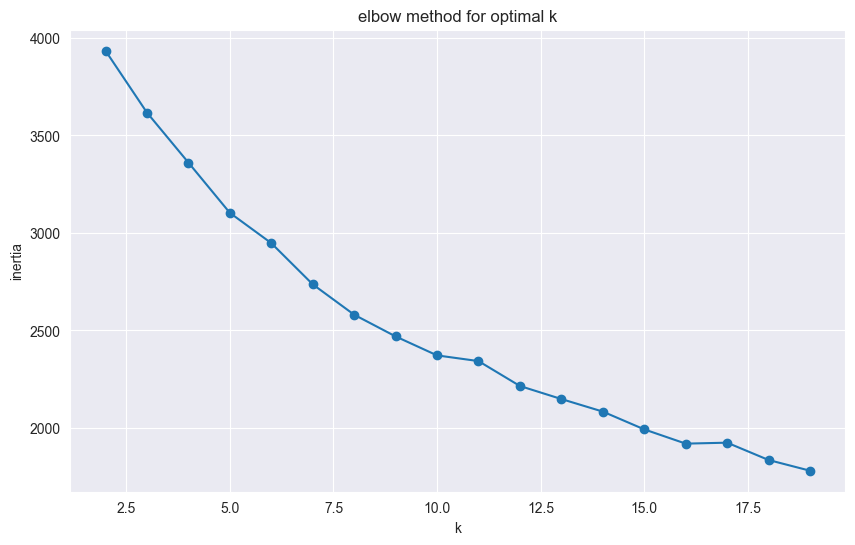

In [34]:
inertia = []
k_range = range(2, 20)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=[10, 6])
plt.plot(k_range, inertia, marker='o')
plt.title('elbow method for optimal k')
plt.xlabel('k')
plt.ylabel('inertia')
plt.grid(True)
plt.show()

In [43]:
optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_pop['cluster'] = kmeans.fit_predict(scaled_data)
print("~*~ number of tracks per cluster:")
print(df_pop['cluster'].value_counts().sort_index())

~*~ number of tracks per cluster:
cluster
0    113
1    143
2     71
3     32
4      7
5     51
Name: count, dtype: int64


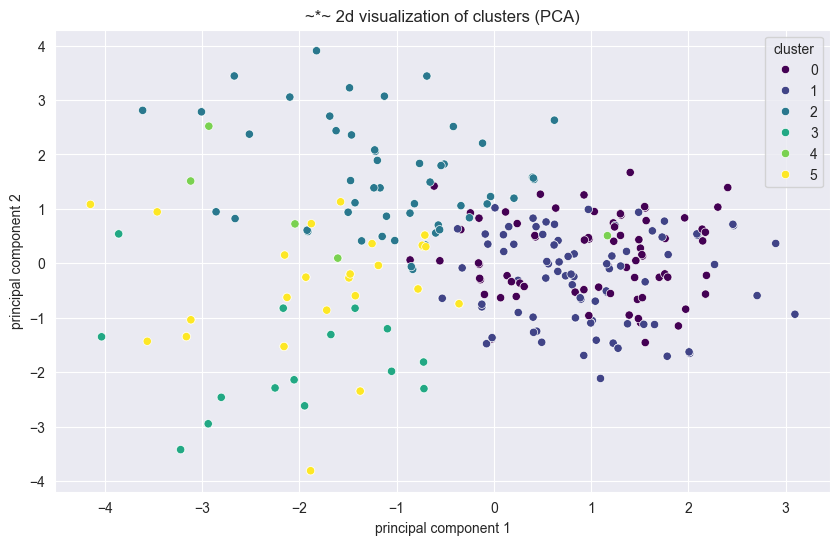

In [36]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
df_pop['pca1'] = pca_data[:, 0]
df_pop['pca2'] = pca_data[:, 1]

plt.figure(figsize=[10, 6])
sns.scatterplot(data=df_pop, x='pca1', y='pca2', hue='cluster', palette='viridis')
plt.title('~*~ 2d visualization of clusters (PCA)')
plt.xlabel('principal component 1')
plt.ylabel('principal component 2')
plt.legend(title='cluster')
plt.show()


~*~ cluster analysis: mean values of features per cluster


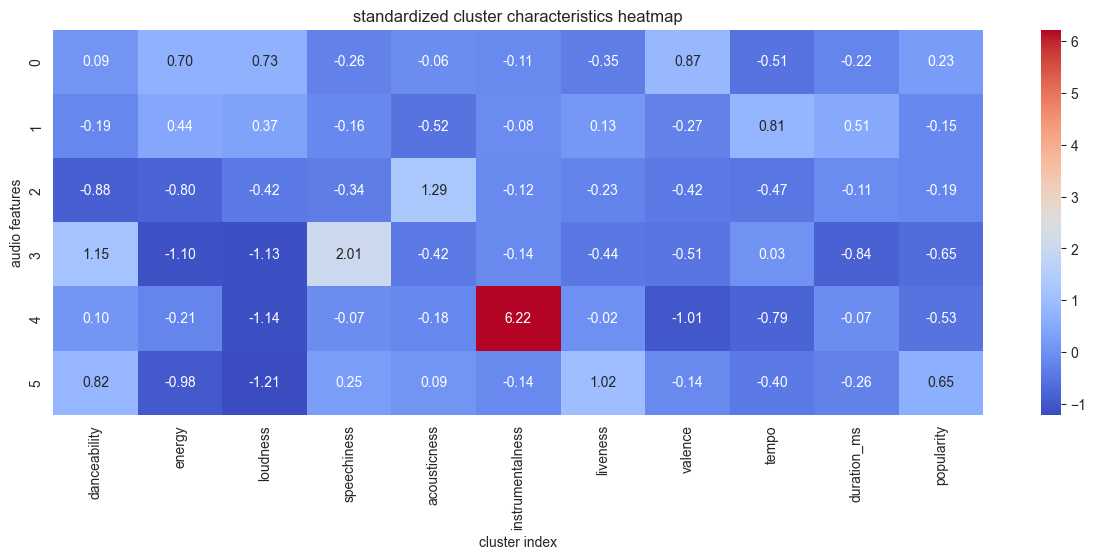

In [44]:
scaled_df = pd.DataFrame(scaled_data, columns=features)
scaled_df['cluster'] = df_pop['cluster'].values
cluster_analysis = scaled_df.groupby('cluster').mean()
print(f"\n~*~ cluster analysis: mean values of features per cluster")

plt.figure(figsize=[15, 5])
sns.heatmap(cluster_analysis, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('standardized cluster characteristics heatmap')
plt.xlabel('cluster index')
plt.ylabel('audio features')
plt.show()

In [45]:
print("\n~*~ first cluster (0): music with positive vibes - highest valence")
print("~*~ second cluster (1): high tempo - highest tempo")
print("~*~ third cluster (2): acoustic/chill - highest acousticness, lowest danceability")
print("~*~ fourth cluster (3): rap/hip-hop - highest speechiness")
print("~*~ fifth cluster (4): instrumental - highest instrumentalness, pure music")
print("~*~ sixth cluster (5): popular live hits - highest liveness and popularity")



~*~ first cluster (0): music with positive vibes - highest valence
~*~ second cluster (1): high tempo - highest tempo
~*~ third cluster (2): acoustic/chill - highest acousticness, lowest danceability
~*~ fourth cluster (3): rap/hip-hop - highest speechiness
~*~ fifth cluster (4): instrumental - highest instrumentalness, pure music
~*~ sixth cluster (5): popular live hits - highest liveness and popularity
